In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("global_ecommerce_sales.csv")

In [22]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

In [23]:
#identificando e tirando valores nulos
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
Year                0
Month               0
dtype: int64

In [24]:
#removendo duplicadas
df.drop_duplicates(inplace= True)

In [25]:
df['Customer_Segment'] = df['Customer_Segment'].str.strip()

In [26]:
df['Region'] = df['Region'].str.lower()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   object        
 1   Order_Date        2000 non-null   datetime64[ns]
 2   Customer_Name     2000 non-null   object        
 3   Customer_Segment  2000 non-null   object        
 4   Country           2000 non-null   object        
 5   Region            2000 non-null   object        
 6   Product_Category  2000 non-null   object        
 7   Product_Name      2000 non-null   object        
 8   Quantity          2000 non-null   int64         
 9   Unit_Price        2000 non-null   float64       
 10  Discount_Percent  2000 non-null   int64         
 11  Total_Sales       2000 non-null   float64       
 12  Shipping_Cost     2000 non-null   float64       
 13  Profit            2000 non-null   float64       
 14  Payment_Method    2000 n

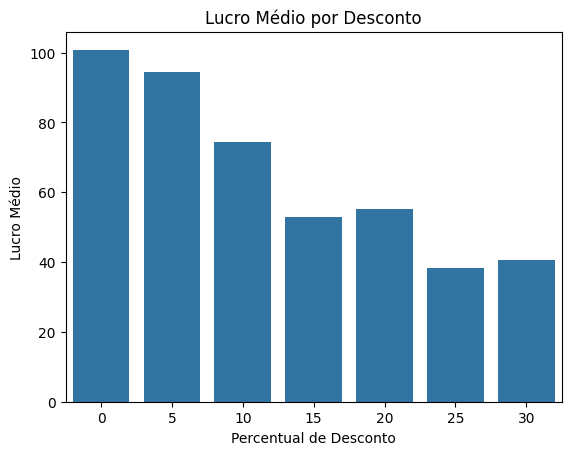

In [27]:
# Qual é a média de Lucro (Profit)
# para cada nível de Desconto (Discount_Percent)

df2 = df[['Discount_Percent', 'Profit']]

desconto = (
    df2.groupby('Discount_Percent')['Profit'].mean().reset_index()
)

sns.barplot(
    data=desconto,
    x='Discount_Percent',
    y='Profit'
)

plt.xlabel('Percentual de Desconto')
plt.ylabel('Lucro Médio')
plt.title('Lucro Médio por Desconto')

plt.show()


In [ ]:
#o que esse dado revela?
#revela que o lucro cai conforme o percentual de desconto aumenta
#porém existe uma anomalia quando o desconto é 20%, o lucro sobe um pouco

In [ ]:
#o que deveriamos fazer com essa informação?
#não dar mais de 20% de desconto

In [33]:
#Quais são as regiões onde o frete é mais caro
#e como isso afeta o lucro médio lá?
df3 = df[['Shipping_Cost', 'Region', 'Profit']]
regioes = df3.groupby('Region')[['Shipping_Cost', 'Profit']].mean().sort_values('Shipping_Cost', ascending=False)
print(regioes)

                      Shipping_Cost     Profit
Region                                        
middle east & africa      15.995385  68.040769
south america             15.444241  76.863770
asia pacific              14.482981  75.224250
europe                    12.304911  90.799523
north america             10.046419  78.287353


In [36]:
#Gere uma tabela agrupada por Region que mostre a
#MÉDIA de Discount_Percent e a MÉDIA de Unit_Price

df4 = df[['Discount_Percent', 'Region', 'Unit_Price', 'Profit']]
media = df4.groupby('Region')[['Discount_Percent', 'Unit_Price']].mean()
media.sort_values('Discount_Percent', ascending= False)

,Discount_Percent,Unit_Price
Region,,
south america,9.293194,78.467853
asia pacific,8.894231,71.095712
europe,8.369781,76.501213
north america,8.365052,71.100173
middle east & africa,8.173077,72.720385


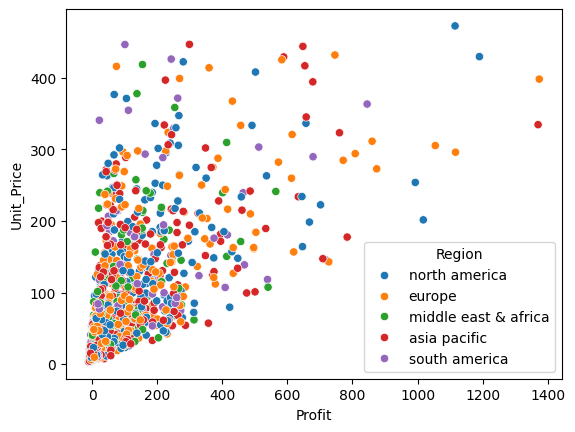

In [39]:
grafico = sns.scatterplot(data = df4, x = 'Profit', y = 'Unit_Price', hue = 'Region')

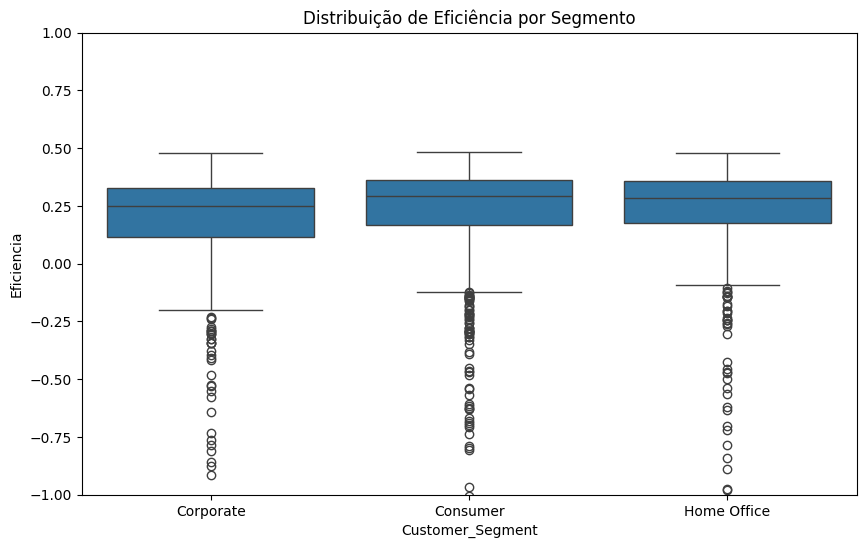

In [52]:
plt.figure(figsize=(10, 6))
# O Boxplot vai te mostrar a mediana, os quartis e onde estão os prejuízos reais
sns.boxplot(data=df5, x='Customer_Segment', y='Eficiencia')

# Dica: Limite o eixo Y para você conseguir enxergar o grosso dos dados 
# (já que alguns prejuízos de -4 esticam demais o gráfico)
plt.ylim(-1, 1) 

plt.title('Distribuição de Eficiência por Segmento')
plt.show()